## SEQUENTIAL CHAIN

In [19]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END


class State(TypedDict):
    question:str
    text:str
    answer:str

def step1(state:State):
    text=state["question"].upper()
    return{
        "text":text
    }

def step2(state:State):
    answer=f"You asked: {state['text']}"

    return{
        "answer":answer
    }

graph=StateGraph(State)

graph.add_node("step1",step1)
graph.add_node("step2",step2)

graph.add_edge(START,"step1")
graph.add_edge("step1","step2")
graph.add_edge("step2",END)

app=graph.compile()

result=app.invoke({
    "question":"what is langgraph?"
})
print(result)


{'question': 'what is langgraph?', 'text': 'WHAT IS LANGGRAPH?', 'answer': 'You asked: WHAT IS LANGGRAPH?'}


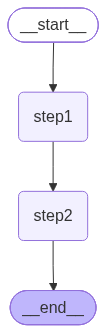

In [20]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))

## PARALLEL CHAIN

In [21]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    question:str
    uppercase:str
    length:str

def uppercase_node(state:State):
    return{
        "uppercase":state["question"].upper()
    }

def length_node(state:State):
    return{
        "length":len(state['question'])
    }


graph=StateGraph(State)

graph.add_node("uppercase",uppercase_node)
graph.add_node("length",length_node)

graph.add_edge(START,"uppercase")
graph.add_edge(START,"length")

graph.add_edge("uppercase",END)
graph.add_edge("length",END)

app=graph.compile()

result=app.invoke({
    "question":"Hello My name is Niko"
})


print(result)



{'question': 'Hello My name is Niko', 'uppercase': 'HELLO MY NAME IS NIKO', 'length': 21}


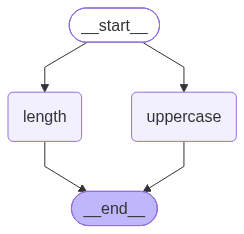

In [22]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))

## ROUTER/CONDITIONAL CHAIN

In [23]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

class State(TypedDict):
    question:str
    result:str

def router(state:State):
    return {}


def decide_next(state: State):

    question = state["question"].lower()

    if "hello" in question:
        return "greeting"

    elif "calculate" in question:
        return "calculator"

    else:
        return "general"

def greeting(state:State):
    return{
        "result":"Hello! How can i help you?"
    }

def calculator(state:State):
    return{
        "result":"This question requires calculation"
    }

def general(state:State):
    return{
        "result":"this is a general question"
    }

graph=StateGraph(State)

graph.add_node("router",router)
graph.add_node("greeting",greeting)
graph.add_node("calculator",calculator)
graph.add_node("general",general)


graph.add_edge(START,"router")

graph.add_conditional_edges(
    "router",
    decide_next,
    {
        "greeting": "greeting",
        "calculator": "calculator",
        "general": "general"

    }
)

graph.add_edge("greeting",END)
graph.add_edge("calculator",END)
graph.add_edge("general",END)

app=graph.compile()

result=app.invoke({
    "question":"hello"
})

print(result)



{'question': 'hello', 'result': 'Hello! How can i help you?'}


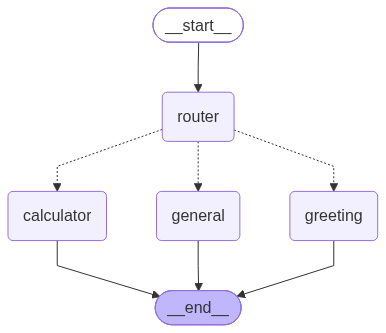

In [24]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))

In [26]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

from langchain_openai import ChatOpenAI


# ============================================================
# 1. DEFINE STATE
# ============================================================

class State(TypedDict):
    messages: Annotated[list, add_messages]


# ============================================================
# 2. CREATE TOOLS
# ============================================================

@tool
def add(a: int, b: int) -> int:
    """Add two numbers."""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b


@tool
def get_weather(city: str) -> str:
    """Get the weather of a city."""
    
    # Just an example
    weather = {
        "Mumbai": "Sunny, 30°C",
        "Delhi": "Cloudy, 27°C",
        "London": "Rainy, 15°C"
    }

    return weather.get(city, "Weather data not available")


tools = [
    add,
    multiply,
    get_weather
]


# ============================================================
# 3. CREATE LLM
# ============================================================

llm = ChatOpenAI(
    model="qwen/qwen3-4b-2507",
    base_url="http://127.0.0.1:1234/v1",
    api_key="dummy",
    temperature=0.1
)


# ============================================================
# 4. BIND TOOLS TO LLM
# ============================================================

llm_with_tools = llm.bind_tools(tools)


# ============================================================
# 5. CREATE LLM NODE
# ============================================================

def chatbot(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }


# ============================================================
# 6. CREATE TOOL NODE
# ============================================================

tool_node = ToolNode(tools)


# ============================================================
# 7. DECISION FUNCTION
# ============================================================

def should_continue(state: State):

    last_message = state["messages"][-1]

    # If LLM requested a tool
    if last_message.tool_calls:
        return "tools"

    # Otherwise finish
    return END


# ============================================================
# 8. BUILD GRAPH
# ============================================================

builder = StateGraph(State)


# Add nodes
builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)


# START → chatbot
builder.add_edge(START, "chatbot")


# chatbot → tools OR END
builder.add_conditional_edges(
    "chatbot",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)


# tools → chatbot
builder.add_edge("tools", "chatbot")


# ============================================================
# 9. COMPILE
# ============================================================

app = builder.compile()


# ============================================================
# 10. RUN GRAPH
# ============================================================

result = app.invoke(
    {
        "messages": [
            HumanMessage(
                content="What is 10 multiplied by 5?"
            )
        ]
    }
)


# ============================================================
# 11. PRINT CONVERSATION
# ============================================================

for message in result["messages"]:

    print("\n--------------------")
    print(type(message).__name__)
    print(message.content)

    tool_calls = getattr(message, "tool_calls", None)

    if tool_calls:
        print("Tool Calls:")
        print(tool_calls)
    


--------------------
HumanMessage
What is 10 multiplied by 5?

--------------------
AIMessage

Tool Calls:
[{'name': 'multiply', 'args': {'a': 10, 'b': 5}, 'id': '443445465', 'type': 'tool_call'}]

--------------------
ToolMessage
50

--------------------
AIMessage
10 multiplied by 5 is 50.


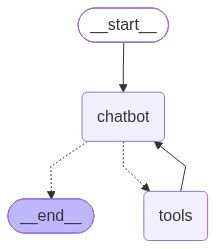

In [27]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))